# 1. Carga y análisis previo del dataset 📚

In [82]:
#Importamos las librerías que se van usar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Cargamos archivo y lo definimos como "cp (CatálogoPelículas)"
df_cp = pd.read_csv('/content/Dataframe_2_CatalogoPeliculasFinal.csv')
# Tabla original
df_cp.head()

,film_id,title_clean,description_clean,category_name,language_name,length,Copias_en_inventario
0,19,Amadeus holy,A emotional display of a pioneer and a technic...,Action,English,113,6
1,21,American circus,A insightful drama of a girl and a astronaut w...,Action,English,129,6
2,29,Antitrust tomatoes,A fateful yarn of a womanizer and a feminist w...,Action,English,168,2
3,56,Barefoot manchurian,A intrepid story of a cat and a student who mu...,Action,English,129,5
4,67,Berets agent,A taut saga of a crocodile and a boy who must ...,Action,English,77,6


In [83]:
# Muestra por pantalla el número de filas/registros y columnas del dataset
print(f"Nº Filas: {df_cp.shape[0]}")
print(f"Nº Columnas: {df_cp.shape[1]}")

Nº Filas: 958
Nº Columnas: 7


In [87]:
# Visualización rápida del resumen estadístico de las variables numéricas
df_cp.describe()

,film_id,length,Copias_en_inventario
count,958.000000,958.000000,958.000000
mean,502.598121,115.490605,4.781837
std,287.541738,40.471844,1.816390
min,1.000000,46.000000,2.000000
25%,256.250000,80.250000,3.000000
50%,504.500000,114.000000,5.000000
75%,751.750000,150.000000,6.000000
max,1000.000000,185.000000,8.000000


# 2. Agrupación por categoría 📈

In [84]:
# Agrupamos por categoría y contamos los IDs de las películas
print(df_cp.columns)
peliculas_por_categoria = df_cp.groupby('category_name')['film_id'].count().sort_values(ascending=False)

print("Conteo de películas por categoría:")
print(peliculas_por_categoria)

Index(['film_id', 'title_clean', 'description_clean', 'category_name',
       'language_name', 'length', 'Copias_en_inventario'],
      dtype='object')
Conteo de películas por categoría:
category_name
Sports         73
Family         67
Foreign        67
Animation      64
Documentary    63
Action         61
Drama          61
New            60
Sci-fi         59
Games          58
Children       58
Comedy         56
Classics       54
Horror         53
Travel         53
Music          51
Name: film_id, dtype: int64


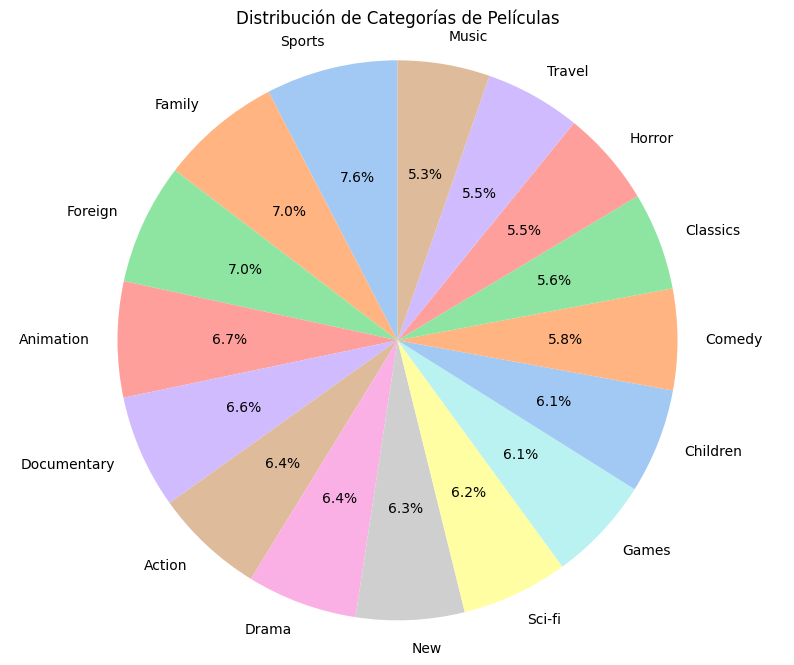

In [85]:
# Creamos gráfico circular para ver mejor las categorías
category_counts = df_cp['category_name'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Distribución de Categorías de Películas')
plt.axis('equal')
plt.show()

/tmp/ipykernel_13287/2673015539.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='categoria', y='total_copias', data=df_inventario, palette=paleta)


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'Sports'),
  Text(1, 0, 'Family'),
  Text(2, 0, 'Foreign'),
  Text(3, 0, 'Animation'),
  Text(4, 0, 'Documentary'),
  Text(5, 0, 'Action'),
  Text(6, 0, 'Drama'),
  Text(7, 0, 'New'),
  Text(8, 0, 'Sci-fi'),
  Text(9, 0, 'Games'),
  Text(10, 0, 'Children'),
  Text(11, 0, 'Comedy'),
  Text(12, 0, 'Classics'),
  Text(13, 0, 'Horror'),
  Text(14, 0, 'Travel'),
  Text(15, 0, 'Music')])

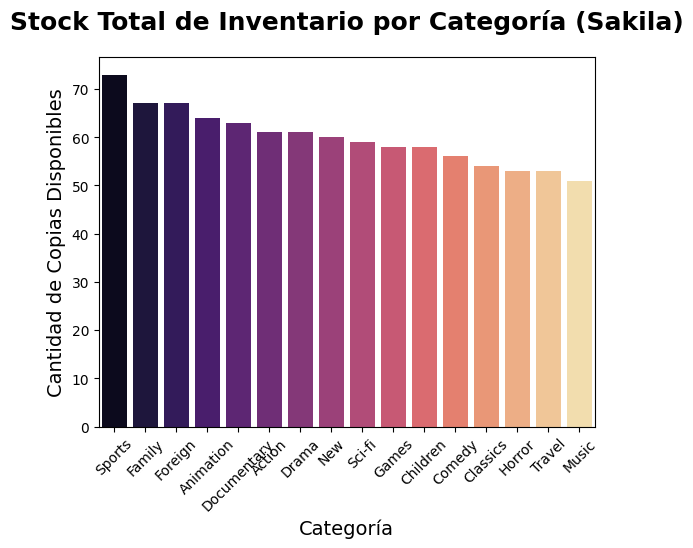

In [89]:
# Vamos a crear un gráfico de barras para mostrar el total de copias por categoría
df_inventario = peliculas_por_categoria.reset_index()
df_inventario.columns = ['categoria', 'total_copias']

paleta = sns.color_palette("magma", len(df_inventario))
ax = sns.barplot(x='categoria', y='total_copias', data=df_inventario, palette=paleta)

plt.title('Stock Total de Inventario por Categoría (Sakila)', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Categoría', fontsize=14)
plt.ylabel('Cantidad de Copias Disponibles', fontsize=14)
plt.xticks(rotation=45)

# 3. Duración de la película ⏰


In [86]:
# Añadimos columna para ver si la película dura más de 120 min
# Mostramos la tabla final
df_cp['is_long_film'] = df_cp['length'] > 120
display(df_cp.head())

,film_id,title_clean,description_clean,category_name,language_name,length,Copias_en_inventario,is_long_film
0,19,Amadeus holy,A emotional display of a pioneer and a technic...,Action,English,113,6,False
1,21,American circus,A insightful drama of a girl and a astronaut w...,Action,English,129,6,True
2,29,Antitrust tomatoes,A fateful yarn of a womanizer and a feminist w...,Action,English,168,2,True
3,56,Barefoot manchurian,A intrepid story of a cat and a student who mu...,Action,English,129,5,True
4,67,Berets agent,A taut saga of a crocodile and a boy who must ...,Action,English,77,6,False
